# 09 · Nazario — структура сценариев (диагностическая LLM-разметка)

**Источник:** `data/raw/collected/nazario.jsonl` (корпус Nazario: legacy mbox + архивы `phishing-2015` …).

**Единица разметки:** одно тело письма после подготовки в этом ноутбуке:
- без заголовков (в сыром JSONL уже поле `text` — тело);
- без HTML-мусора (как при сборке в `01_explore_sources`);
- нормализованный whitespace;
- опционально маскировка URL (`[URL]`) — включите `MASK_URLS_FOR_ANNOTATION`, если нужна симметрия с финальным пайплайном.

**Выборка:** по умолчанию **125 legacy** + **125 modern** (`source` начинается с `phishing-20` → modern, иначе legacy). Если в одном пуле не хватает строк, недостающее добирается из другого (с тем же сидом). Файл выборки фиксируется: `block_ab/samples/nazario_legacy_modern_250.jsonl`.

**Выход:** `data/interim/annotated/nazario_scenario_annotated.jsonl` — плоские строки: исходные поля Nazario + `scenario_family`, `institution_type`, `core_candidate`, бинарные признаки (`yes`/`no`), `annotation_confidence` (из поля `confidence` модели), `annotation_model`, `annotated_at`.

**Кеш:** повторный запуск не дублирует записи (ключ `md5` от **того же** текста, что уходит в модель и сохраняется в поле `text`).

**Запуск:** задайте `MAX_NEW_THIS_RUN` и при необходимости `BATCH_SIZE` / `SLEEP_SEC`; гоняйте ячейку аннотации частями, пока не наберёте ~250 строк.

In [12]:
# CONFIG
from __future__ import annotations

RANDOM_SEED = 42
N_LEGACY_TARGET = 125
N_MODERN_TARGET = 125
BATCH_SIZE = 10
SLEEP_SEC = 2.5
MAX_NEW_THIS_RUN = 100
ANNOTATION_MODEL = "openai/gpt-4o-mini"

# Нормализация пробелов всегда; URL — по желанию (в raw Nazario ссылки часто не замаскированы)
MASK_URLS_FOR_ANNOTATION = True

In [2]:
# Setup
import importlib.util
import json
import os
import random
import re
import time
from datetime import datetime, timezone
from pathlib import Path

from dotenv import load_dotenv
from openai import OpenAI, APIError, RateLimitError
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
from tqdm.auto import tqdm
import pandas as pd


def _find_v2_root() -> Path:
    """Resolve v2 root: must contain data/raw/collected (Nazario cache lives there)."""
    candidate = Path(globals().get("__vsc_ipynb_file__", globals().get("__file__", "."))).resolve()
    for p in [candidate, *candidate.parents]:
        if (p / "pyproject.toml").exists() and (p / "data" / "raw" / "collected").exists():
            return p
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists() and (p / "data" / "raw" / "collected").exists():
            return p
    raise RuntimeError("Cannot find v2/ project root (need pyproject.toml + data/raw/collected)")


V2_ROOT = _find_v2_root()
RAW_DIR = V2_ROOT / "data" / "raw" / "collected"
INTERIM = V2_ROOT / "data" / "interim" / "annotated"
BLOCK_AB = INTERIM / "block_ab"
SAMP_DIR = BLOCK_AB / "samples"
OUT_FLAT = INTERIM / "nazario_scenario_annotated.jsonl"

for d in (BLOCK_AB, SAMP_DIR, INTERIM):
    d.mkdir(parents=True, exist_ok=True)

_common_path = V2_ROOT / "notebooks" / "02_dataset_design" / "_ann_common.py"
spec = importlib.util.spec_from_file_location("_ann_common", _common_path)
ac = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ac)

env_file = V2_ROOT / ".env"
load_dotenv(env_file if env_file.exists() else None)
api_key = os.environ.get("OPENROUTER_API_KEY", "")
if not api_key:
    raise EnvironmentError("OPENROUTER_API_KEY missing in v2/.env")
client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=api_key)
print("OUT_FLAT =", OUT_FLAT)

OUT_FLAT = /Users/askar/projects/antifraud-deepfake-detection/v2/data/interim/annotated/nazario_scenario_annotated.jsonl


In [3]:
def nazario_time_band(r: dict) -> str:
    s = (r.get("source") or "").strip()
    if s.startswith("phishing-20"):
        return "modern"
    return "legacy"


def collapse_whitespace(t: str) -> str:
    return re.sub(r"\s+", " ", (t or "").strip())


def mask_urls_symmetric(t: str) -> str:
    return re.sub(r"https?://\S+", "[URL]", t, flags=re.I)


def prepare_body(r: dict) -> str:
    t = r.get("text") or ""
    t = collapse_whitespace(t)
    if MASK_URLS_FOR_ANNOTATION:
        t = mask_urls_symmetric(t)
    return t


def stratified_legacy_modern(
    legacy: list[dict],
    modern: list[dict],
    n_leg: int,
    n_mod: int,
    seed: int,
) -> list[dict]:
    rng = random.Random(seed)
    la, ma = list(legacy), list(modern)
    rng.shuffle(la)
    rng.shuffle(ma)
    take_l = min(n_leg, len(la))
    take_m = min(n_mod, len(ma))
    pl, pm = la[:take_l], ma[:take_m]
    need = (n_leg + n_mod) - (len(pl) + len(pm))
    remainder = la[take_l:] + ma[take_m:]
    rng.shuffle(remainder)
    extra = remainder[: max(0, need)]
    out = pl + pm + extra
    rng.shuffle(out)
    return out


def build_nazario_sample() -> list[dict]:
    all_rows = ac.load_jsonl(RAW_DIR / "nazario.jsonl")
    all_rows = [r for r in all_rows if (r.get("text") or "").strip()]
    uniq = ac.dedupe_records_by_text_sha(all_rows, text_key="text")
    legacy = [r for r in uniq if nazario_time_band(r) == "legacy"]
    modern = [r for r in uniq if nazario_time_band(r) == "modern"]
    print(f"Unique rows: {len(uniq):,}  (legacy {len(legacy):,} | modern {len(modern):,})")
    picked = stratified_legacy_modern(legacy, modern, N_LEGACY_TARGET, N_MODERN_TARGET, RANDOM_SEED)
    for r in picked:
        r["_time_band"] = nazario_time_band(r)
    return picked


sample_path = SAMP_DIR / "nazario_legacy_modern_250.jsonl"
sample_naz = ac.ensure_sample(sample_path, build_nazario_sample)
print("Sample path:", sample_path)
print("Sample size:", len(sample_naz))
print(sample_naz[0].get("_time_band") if sample_naz else "empty")

Unique rows: 5,819  (legacy 2,934 | modern 2,885)
Created sample nazario_legacy_modern_250.jsonl  n=250
Sample path: /Users/askar/projects/antifraud-deepfake-detection/v2/data/interim/annotated/block_ab/samples/nazario_legacy_modern_250.jsonl
Sample size: 250
legacy


In [4]:
SYSTEM_PROMPT = """You are annotating phishing email messages for a research dataset on LLM-generated text detection in anti-fraud systems.

Your task is NOT to summarize the email.
Your task is to assign a small set of structured labels describing the phishing scenario.

You must use ONLY the allowed labels.

Return output as strict JSON with the following keys:

{
  "scenario_family": "...",
  "institution_type": "...",
  "core_candidate": "...",
  "has_credential_request": "yes|no",
  "has_urgency": "yes|no",
  "has_threat_or_consequence": "yes|no",
  "has_financial_pretence": "yes|no",
  "has_link_or_cta": "yes|no",
  "confidence": "high|medium|low"
}

Allowed values for "scenario_family":
- account_verification
- account_suspension
- suspicious_activity_or_login
- password_reset
- card_verification_or_card_issue
- kyc_or_identity_update
- refund_or_reward_lure
- invoice_or_payment_lure
- generic_financial_phishing
- nonfinancial_phishing
- unclear_other

Definitions:
- account_verification: asks the user to verify or confirm account details or access
- account_suspension: claims account will be suspended/closed/limited unless action is taken
- suspicious_activity_or_login: claims unusual login, suspicious activity, security incident, fraud alert
- password_reset: asks for password reset or claims reset is required
- card_verification_or_card_issue: mentions blocked card, card issue, card verification, card reactivation
- kyc_or_identity_update: asks for identity documents, identity confirmation, compliance update
- refund_or_reward_lure: promises refund, cashback, reward, prize, compensation
- invoice_or_payment_lure: references invoice, payment, billing, transaction, transfer, amount due
- generic_financial_phishing: clearly finance/payment-related phishing but no narrower label fits well
- nonfinancial_phishing: phishing-like message but not clearly in banking/payment/financial anti-fraud domain
- unclear_other: meaning is too unclear or mixed to classify confidently

Allowed values for "institution_type":
- bank_or_card
- payment_service
- ecommerce_or_marketplace
- telecom_or_isp
- government_or_tax
- generic_business
- unclear

Definitions:
- bank_or_card: bank, debit/credit card provider, card security
- payment_service: PayPal-like service, payment processor, wallet, money transfer
- ecommerce_or_marketplace: shopping site, order/account marketplace
- telecom_or_isp: internet, mobile, phone, communications provider
- government_or_tax: tax, customs, state service, government office
- generic_business: company/business/service but unclear sector
- unclear: institution type cannot be inferred

Allowed values for "core_candidate":
- yes
- maybe
- no

Meaning:
- yes: clearly fits the intended phishing_email core family for the dataset
- maybe: somewhat relevant but less canonical or less clearly financial
- no: not suitable as a core phishing_email example

Annotation rules:
1. Choose the most specific scenario_family that fits.
2. If the email is clearly phishing-like but not obviously financial, use nonfinancial_phishing.
3. If the email is too short, corrupted, or ambiguous, use unclear_other.
4. Mark has_credential_request = yes only if the text asks for login, password, account details, identity data, or similar credentials/verification data.
5. Mark has_link_or_cta = yes if there is a link, button-like instruction, reply/call instruction, or any clear action request.
6. Use confidence=low only when the text is too ambiguous or partially broken.
7. Do not explain your answer. Output JSON only.
"""

OK_SCENARIO = {
    "account_verification",
    "account_suspension",
    "suspicious_activity_or_login",
    "password_reset",
    "card_verification_or_card_issue",
    "kyc_or_identity_update",
    "refund_or_reward_lure",
    "invoice_or_payment_lure",
    "generic_financial_phishing",
    "nonfinancial_phishing",
    "unclear_other",
}
OK_INST = {
    "bank_or_card",
    "payment_service",
    "ecommerce_or_marketplace",
    "telecom_or_isp",
    "government_or_tax",
    "generic_business",
    "unclear",
}
OK_CORE = {"yes", "maybe", "no"}
OK_YN = {"yes", "no"}
OK_CONF = {"high", "medium", "low"}


def wrap_nazario_user(body: str) -> list[dict]:
    user = f"Email body to annotate:\n\n{body}"
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user},
    ]


def validate_nazario_ann(d: dict) -> dict:
    sf = d.get("scenario_family", "unclear_other")
    if sf not in OK_SCENARIO:
        sf = "unclear_other"
    it = d.get("institution_type", "unclear")
    if it not in OK_INST:
        it = "unclear"
    cc = d.get("core_candidate", "maybe")
    if cc not in OK_CORE:
        cc = "maybe"

    def yn(x, default="no"):
        v = (x if isinstance(x, str) else str(x)).lower().strip()
        return v if v in OK_YN else default

    conf = d.get("confidence", "low")
    if conf not in OK_CONF:
        conf = "low"
    return {
        "scenario_family": sf,
        "institution_type": it,
        "core_candidate": cc,
        "has_credential_request": yn(d.get("has_credential_request")),
        "has_urgency": yn(d.get("has_urgency")),
        "has_threat_or_consequence": yn(d.get("has_threat_or_consequence")),
        "has_financial_pretence": yn(d.get("has_financial_pretence")),
        "has_link_or_cta": yn(d.get("has_link_or_cta")),
        "confidence": conf,
    }


@retry(
    retry=retry_if_exception_type((RateLimitError, APIError)),
    wait=wait_exponential(multiplier=2, min=2, max=45),
    stop=stop_after_attempt(6),
)
def call_json(messages: list[dict]) -> dict:
    resp = client.chat.completions.create(
        model=ANNOTATION_MODEL,
        messages=messages,
        response_format={"type": "json_object"},
        temperature=0,
        max_tokens=512,
    )
    return json.loads(resp.choices[0].message.content)

In [13]:
# Annotate (batched + pause); append flat rows only for new md5 keys (по тексту, уходящему в модель)
idx = ac.load_flat_annotation_index(OUT_FLAT)


def row_key(r: dict) -> str:
    return ac.md5_text_key(prepare_body(r))


pending = [r for r in sample_naz if row_key(r) not in idx]
print(f"Already annotated: {len(idx):,} | Pending in sample: {len(pending):,}")


def run_batch():
    n_done = 0
    batch_i = 0
    for r in tqdm(pending[:MAX_NEW_THIS_RUN], desc="nazario_scenario"):
        body = prepare_body(r)
        k = ac.md5_text_key(body)
        if k in idx:
            continue
        try:
            raw_ann = call_json(wrap_nazario_user(body))
            ann = validate_nazario_ann(raw_ann)
        except Exception as e:
            ann = validate_nazario_ann({})
            ann["_error"] = str(e)[:200]
        ts = datetime.now(timezone.utc).isoformat()
        raw_flat = {kk: vv for kk, vv in r.items() if not str(kk).startswith("_")}
        raw_flat["text"] = body
        raw_flat["time_band"] = r.get("_time_band") or nazario_time_band(r)
        extra = {
            "institution_type": ann["institution_type"],
            "core_candidate": ann["core_candidate"],
            "has_credential_request": ann["has_credential_request"],
            "has_urgency": ann["has_urgency"],
            "has_threat_or_consequence": ann["has_threat_or_consequence"],
            "has_financial_pretence": ann["has_financial_pretence"],
            "has_link_or_cta": ann["has_link_or_cta"],
        }
        if "_error" in ann:
            extra["_error"] = ann["_error"]
        flat = ac.make_flat_record(
            raw_flat,
            scenario_family=ann["scenario_family"],
            annotation_confidence=ann["confidence"],
            annotation_model=ANNOTATION_MODEL,
            annotated_at=ts,
            extra=extra,
        )
        ac.append_jsonl(OUT_FLAT, flat)
        idx[k] = flat
        n_done += 1
        batch_i += 1
        if batch_i >= BATCH_SIZE:
            batch_i = 0
            time.sleep(SLEEP_SEC)
    print(f"New annotations this run: {n_done}")


run_batch()
print("Total annotated rows (with scenario_family):", len(ac.load_flat_annotation_index(OUT_FLAT)))

Already annotated: 60 | Pending in sample: 190


nazario_scenario:   0%|          | 0/100 [00:00<?, ?it/s]

New annotations this run: 100
Total annotated rows (with scenario_family): 160


--- scenario_family ---
scenario_family
account_suspension                 49
nonfinancial_phishing              23
suspicious_activity_or_login       18
unclear_other                      18
invoice_or_payment_lure            13
kyc_or_identity_update             13
account_verification                9
password_reset                      7
refund_or_reward_lure               5
card_verification_or_card_issue     3
generic_financial_phishing          2
Name: count, dtype: int64


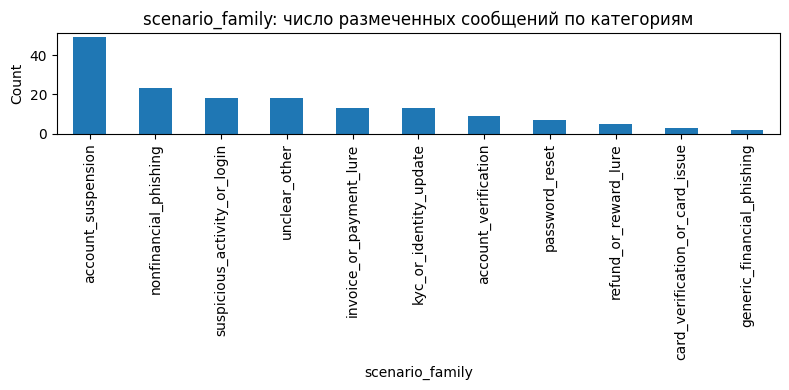


--- institution_type ---
institution_type
generic_business            37
bank_or_card                37
unclear                     33
payment_service             27
ecommerce_or_marketplace    25
government_or_tax            1
Name: count, dtype: int64

--- core_candidate ---
core_candidate
yes      115
maybe     30
no        15
Name: count, dtype: int64

--- binary flags (yes rate) ---
has_credential_request {'yes': np.int64(92), 'no': np.int64(68)}
has_urgency {'yes': np.int64(107), 'no': np.int64(53)}
has_threat_or_consequence {'yes': np.int64(95), 'no': np.int64(65)}
has_financial_pretence {'no': np.int64(107), 'yes': np.int64(53)}
has_link_or_cta {'yes': np.int64(142), 'no': np.int64(18)}

--- annotation_confidence ---
annotation_confidence
high      106
medium     38
low        16
Name: count, dtype: int64

--- time_band ---
time_band
legacy    82
modern    78
Name: count, dtype: int64


In [15]:
# Распределения по накопленному кешу
import matplotlib.pyplot as plt

rows = ac.load_jsonl(OUT_FLAT)
df = pd.DataFrame([r for r in rows if r.get("scenario_family")])
if df.empty:
    print("No annotated rows yet.")
else:
    print("--- scenario_family ---")
    vc_scen = df["scenario_family"].value_counts()
    print(vc_scen)
    # barplot по категориям
    plt.figure(figsize=(8, 4))
    vc_scen.plot(kind="bar")
    plt.title("scenario_family: число размеченных сообщений по категориям")
    plt.xlabel("scenario_family")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    print("\n--- institution_type ---")
    print(df["institution_type"].value_counts())
    print("\n--- core_candidate ---")
    print(df["core_candidate"].value_counts())
    print("\n--- binary flags (yes rate) ---")
    for c in (
        "has_credential_request",
        "has_urgency",
        "has_threat_or_consequence",
        "has_financial_pretence",
        "has_link_or_cta",
    ):
        if c in df.columns:
            vc = df[c].value_counts()
            print(c, dict(vc))
    print("\n--- annotation_confidence ---")
    print(df["annotation_confidence"].value_counts())
    if "time_band" in df.columns:
        print("\n--- time_band ---")
        print(df["time_band"].value_counts())